### Macro timing: do the regime models call the good start dates?


The champion's edge is start-time dependent (rolling sweep: ann_return −24%..+109%).
If a macro score on the start date correlates with the forward 12m return, it's a timing
lever. M03's own doc says it's a *coincident* descriptor, not a forward predictor — so a
flat/near-zero correlation here would *confirm* that, and a positive one would be news.

In [3]:
import sys, hashlib, json
from pathlib import Path

def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d / "config.py").exists() and (d / "src").is_dir():
            return d
    raise RuntimeError(f"repo root not found above {p}")

ROOT = _repo_root()
sys.path.insert(0, str(ROOT))
DB = ROOT / "data" / "market_data.duckdb"        # Path; str() at call sites

import json
import pandas as pd
from src.pipeline.m03_regime import M03RegimeCalculator
from src.pipeline.risk_5_factor import RiskFiveFactorCalculator

SWEEP = ROOT / "data" / "selection_sweep" / "starttime" / "champion" / "rolling" / "summary.json"
sweep = pd.DataFrame(json.load(open(SWEEP))["cells"])
sweep = sweep[sweep["sharpe"].notna()].copy()
sweep["start"] = pd.to_datetime(sweep["start"])
lo, hi = sweep["start"].min().strftime("%Y-%m-%d"), sweep["start"].max().strftime("%Y-%m-%d")
print(f"{len(sweep)} cells · starts {lo}..{hi}")

# M03 (0-100 score + pillars) over the sweep span. Live calc — parquet is stale (<=2026-01-31).
m03 = M03RegimeCalculator().calculate_history_vectorized(lo, hi, freq="D")
m03 = m03[["score", "trend_score", "liquidity_score", "risk_appetite_score"]].rename(
    columns={"score": "m03_score"})

# 5-factor exposure model (0-1 target_exposure, weighted_z, veto)
r5 = RiskFiveFactorCalculator(db_path=str(DB)).compute_history(start_date=lo)
r5 = r5[["target_exposure", "weighted_z", "rolling_percentile", "veto_flag"]]

# as-of join: macro value on-or-before each start date (start dates are month-anchored,
# may land on a non-trading day — backward asof avoids NaN)
def asof_join(left, right, cols):
    r = right.sort_index()
    out = pd.merge_asof(left.sort_values("start"), r[cols], left_on="start",
                        right_index=True, direction="backward")
    return out

df = asof_join(sweep, m03, m03.columns.tolist())
df = asof_join(df, r5, r5.columns.tolist())
df[["start", "ann_return", "sharpe", "m03_score", "target_exposure", "weighted_z", "veto_flag"]].round(3)

INFO:src.pipeline.m03_regime:Calculating M03 regime history (vectorized, T+1 lag) from 2021-01-01 to 2025-05-01
INFO:src.pipeline.m03_regime:Calculated 1380 regime observations
INFO:src.pipeline.risk_5_factor:Loading 5-factor model inputs from DuckDB...


53 cells · starts 2021-01-01..2025-05-01


INFO:src.pipeline.risk_5_factor:Loaded 9192 rows of input data (1990-01-02 to 2026-07-02)
INFO:src.pipeline.risk_5_factor:Computing raw factors...
INFO:src.pipeline.risk_5_factor:Computing rolling z-scores (2555d)...
INFO:src.pipeline.risk_5_factor:Computing weighted z and rolling percentile (1260d, may take ~20s)...
INFO:src.pipeline.risk_5_factor:Scored 5160 rows with target_exposure


,start,ann_return,sharpe,m03_score,target_exposure,weighted_z,veto_flag
0,2021-01-01,1.091,1.989,NaN,NaN,NaN,NaN
1,2021-02-01,-0.242,-0.488,NaN,1.00,-0.643,False
2,2021-03-01,0.862,1.718,NaN,1.00,-0.628,False
3,2021-04-01,0.434,1.051,NaN,1.00,-0.698,False
4,2021-05-01,0.488,1.052,NaN,1.00,-0.921,False
5,2021-06-01,0.584,1.165,NaN,1.00,-0.634,False
6,2021-07-01,0.338,0.862,NaN,1.00,-0.659,False
7,2021-08-01,0.302,0.808,79.7,1.00,-0.484,False
8,2021-09-01,0.515,1.164,87.4,1.00,-0.720,False
9,2021-10-01,0.425,1.028,45.0,0.85,-0.273,False


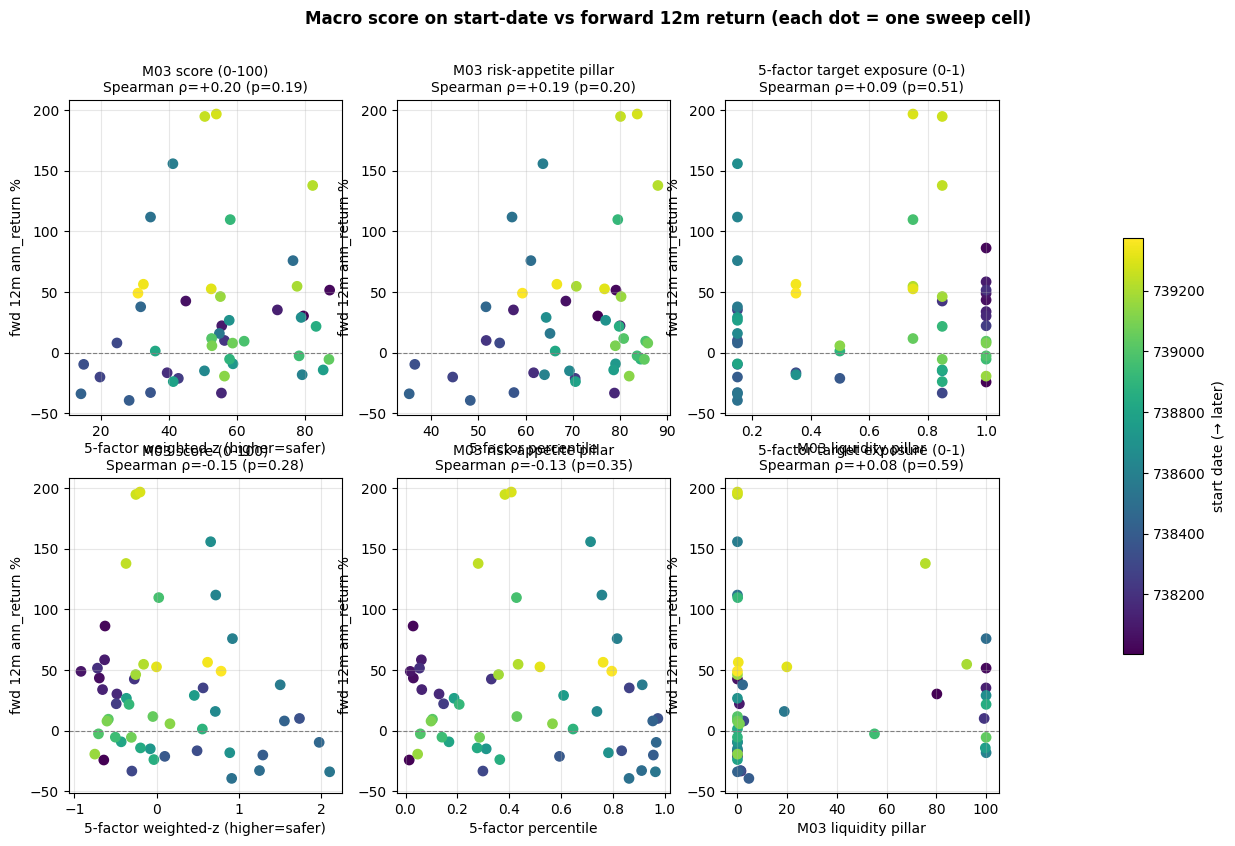

: 

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

SIGNALS = [("m03_score", "M03 score (0-100)"),
           ("risk_appetite_score", "M03 risk-appetite pillar"),
           ("target_exposure", "5-factor target exposure (0-1)"),
           ("weighted_z", "5-factor weighted-z (higher=safer)"),
           ("rolling_percentile", "5-factor percentile"),
           ("liquidity_score", "M03 liquidity pillar")]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (col, label) in zip(axes.ravel(), SIGNALS):
    x, y = df[col].astype(float), df["ann_return"].astype(float) * 100
    rho, p = spearmanr(x, y, nan_policy="omit")
    sc = ax.scatter(x, y, c=df["start"].map(pd.Timestamp.toordinal), cmap="viridis", s=45)
    ax.axhline(0, color="grey", ls="--", lw=0.8)
    ax.set_xlabel(label); ax.set_ylabel("fwd 12m ann_return %")
    ax.set_title(f"{label}\nSpearman ρ={rho:+.2f} (p={p:.2f})", fontsize=10)
    ax.grid(alpha=0.3)
cb = fig.colorbar(sc, ax=axes, shrink=0.6, pad=0.1)
cb.set_label("start date (→ later)")
fig.suptitle("Macro score on start-date vs forward 12m return (each dot = one sweep cell)",
             fontweight="bold")
plt.show()

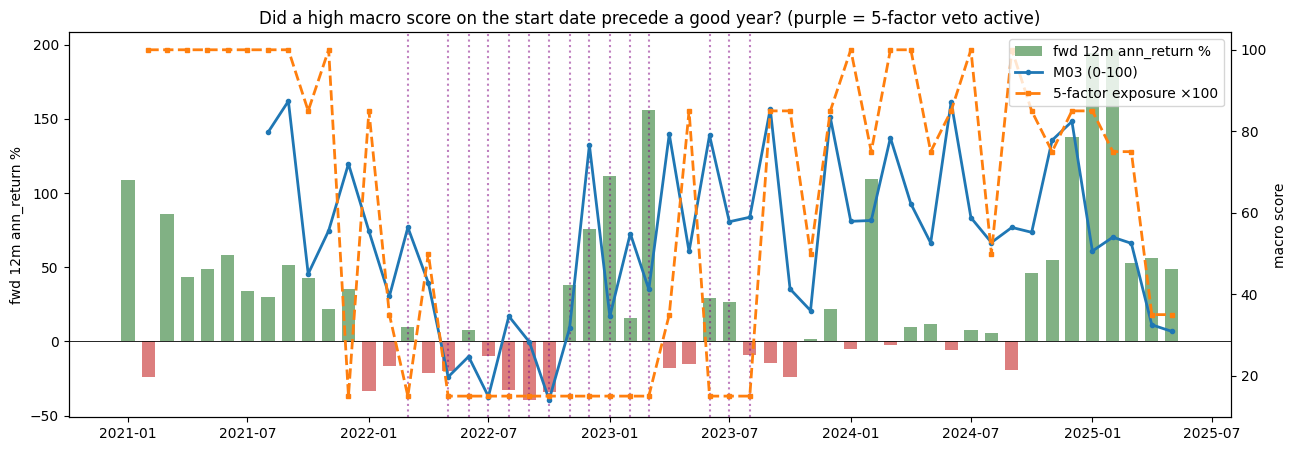

In [6]:
fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.bar(df["start"], df["ann_return"] * 100, width=20,
        color=["#2e7d32" if v > 0 else "#c62828" for v in df["ann_return"]],
        alpha=0.6, label="fwd 12m ann_return %")
ax1.axhline(0, color="black", lw=0.6); ax1.set_ylabel("fwd 12m ann_return %")
ax2 = ax1.twinx()
ax2.plot(df["start"], df["m03_score"], color="#1f77b4", lw=2, marker="o", ms=3, label="M03 (0-100)")
ax2.plot(df["start"], df["target_exposure"] * 100, color="#ff7f0e", lw=2, ls="--",
         marker="s", ms=3, label="5-factor exposure ×100")
ax2.set_ylabel("macro score")
# mark 5-factor vetoes
for _, r in df[df["veto_flag"] == True].iterrows():
    ax1.axvline(r["start"], color="purple", ls=":", alpha=0.5)
ax1.set_title("Did a high macro score on the start date precede a good year? "
              "(purple = 5-factor veto active)")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88)); plt.show()

In [7]:
# If the macro model is a timing lever, high-regime starts should out-earn low-regime starts.
df["m03_bucket"] = pd.cut(df["m03_score"], [0, 45, 60, 100],
                          labels=["neutral/bear <45", "bull 45-60", "strong_bull >60"])
by_regime = df.groupby("m03_bucket", observed=True)["ann_return"].agg(
    ["count", "mean", "median", lambda s: (s > 0).mean()]).round(3)
by_regime.columns = ["n_starts", "mean_ann_ret", "median_ann_ret", "hit_rate"]
print(by_regime)
print("\nVeto-active vs veto-off start dates:")
print(df.groupby("veto_flag")["ann_return"].agg(["count", "mean", "median"]).round(3))

                  n_starts  mean_ann_ret  median_ann_ret  hit_rate
m03_bucket                                                        
neutral/bear <45        16         0.165          -0.042     0.500
bull 45-60              17         0.363           0.116     0.706
strong_bull >60         13         0.311           0.290     0.692

Veto-active vs veto-off start dates:
           count   mean  median
veto_flag                      
False         37  0.326   0.221
True          15  0.217   0.100


### Read

- **Spearman ρ (Cell C):** |ρ| < ~0.3 with p>0.1 on all six ⇒ no start-timing alpha —
  *confirms* M03 is coincident (regime_model.md §2/§6). A clean positive ρ on `target_exposure`
  or `weighted_z` would be the exception worth chasing (5-factor is the exposure model, not M03).
- **Regime buckets (Cell E):** if strong_bull-start mean ann_return ≈ neutral-start, the score
  doesn't pick good entry windows. If veto-off >> veto-on, the *veto* is the usable lever
  (matches the regime_model.md §8 roadmap item: veto_flag is the one forward-negative signal).